# 신용카드 채무불이행 고객 예측 -

https://www.kaggle.com/datasets/uciml/default-of-credit-card-clients-dataset

In [ ]:
# !pip install xlrd --break-system-packages


# 전체 작업 순서

0. **데이터 로딩 (Data Loading)**  
1. **데이터 이해 (Data Understanding)**  
2. **EDA (탐색적 데이터 분석)**  
3. **데이터 전처리 (Data Preprocessing)**  
4. **데이터 분할 (Train / Test Split)**  
5. **Baseline 모델 구축**  
6. **모델 비교 (Model Selection)**  
7. **평가 지표 설정 (Evaluation Metrics)**  
8. **교차 검증 (Cross Validation)**  
9. **하이퍼파라미터 튜닝 (Hyperparameter Tuning)**  
10. **Feature Importance 분석**  
11. **최종 모델 선택 및 평가**

# 0. 데이터 로딩

## Library Loading

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# 그래프 기본 스타일
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_theme(style="whitegrid")

# 경고 메시지 숨기기(선택)
import warnings
warnings.filterwarnings("ignore")

## 데이터 로딩

In [27]:
import pandas as pd
import urllib.request
import os

os.makedirs('./data', exist_ok=True)

# UCI 원본
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00350/default%20of%20credit%20card%20clients.xls"
urllib.request.urlretrieve(url, './data/UCI_Credit_Card.xls')

# xls 읽기
org_df = pd.read_excel('./data/UCI_Credit_Card.xls', header=1)
org_df.to_csv('./data/UCI_Credit_Card_1.csv', index=False)

card_df = org_df.copy()
print(org_df.shape)

(30000, 25)


# 1.Data 이해 및 EDA (Exploratory Data Analysis)

## EDA 작업 순서
1. 데이터 크기 / head / info
2. 타깃 분포 확인
3. 결측치 / 중복 확인
4. 범주형 변수 분포 확인
5. 수치형 변수 분포 및 이상치 확인
6. 타깃과 변수 관계 확인
7. 상관관계 확인
8. 모델링 시사점 정리

## 1.3 데이터 확인/조사

In [20]:
org_df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [21]:
org_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 non-null  int64
 14  BILL_AMT3        

In [22]:
display(org_df.describe())

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


## 1.4 타깃 변수 분포 확인

default payment next month
0    23364
1     6636
Name: count, dtype: int64

default payment next month
0    0.7788
1    0.2212
Name: proportion, dtype: float64


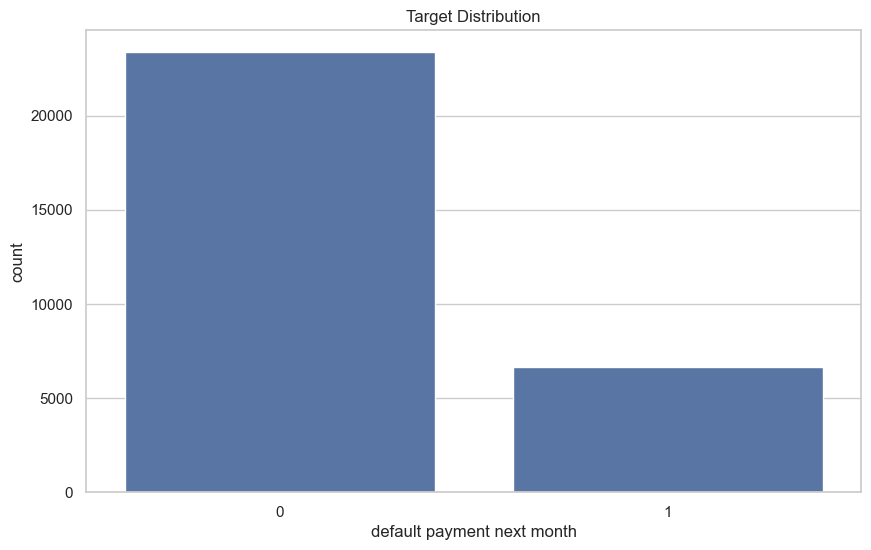

In [23]:
target_col = 'default payment next month'

print(org_df[target_col].value_counts())
print()
print(org_df[target_col].value_counts(normalize=True))

sns.countplot(data=org_df, x=target_col)
plt.title("Target Distribution")
plt.show()

* 이 데이터는 보통 부도 비율이 낮은 불균형 데이터이므로, 이후 평가 지표를 Accuracy만 쓰면 안 된다

## 1.5 결측치 확인

In [24]:
missing = org_df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print("결측치가 있는 컬럼 수:", missing.shape[0])
display(missing)

결측치가 있는 컬럼 수: 0


Series([], dtype: int64)

## 1.6 중복 확인

In [25]:
print("중복 행 수:", org_df.duplicated().sum())

중복 행 수: 0


## 1.7. 범주형 컬럼의 값 분포 확인

* SEX : 1=male, 2=female
* EDUCATION : 1=graduate school, 2=university, 3=high school, 4=others, 5=unknown, 6=unknown
* MARRIAGE : 1=married, 2=single, 3=others
* PAY_0, PAY_2, PAY_3, PAY_4, PAY_5, PAY_6

In [26]:
cat_cols = ['SEX', 'EDUCATION', 'MARRIAGE',
                 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

for col in cat_cols:
    print(f"\n[{col}] value counts")
    display(org_df[col].value_counts(dropna=False).sort_index())


[SEX] value counts


SEX
1    11888
2    18112
Name: count, dtype: int64


[EDUCATION] value counts


EDUCATION
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51
Name: count, dtype: int64


[MARRIAGE] value counts


...

PAY_4
-2     4348
-1     5687
 0    16455
 1        2
 2     3159
 3      180
 4       69
 5       35
 6        5
 7       58
 8        2
Name: count, dtype: int64


[PAY_5] value counts


PAY_5
-2     4546
-1     5539
 0    16947
 2     2626
 3      178
 4       84
 5       17
 6        4
 7       58
 8        1
Name: count, dtype: int64


[PAY_6] value counts


PAY_6
-2     4895
-1     5740
 0    16286
 2     2766
 3      184
 4       49
 5       13
 6       19
 7       46
 8        2
Name: count, dtype: int64

## 1.7.2 범주형 컬럼의 값 - 수정

In [ ]:
# EDUCATION : unknown, others, undefined => ohters
card_df['EDUCATION'] = card_df['EDUCATION'].replace([0,5,6],4)

# MARRIAGE
card_df['MARRIAGE'] = card_df['MARRIAGE'].replace([0,],3)

pay_cols = ['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']

for col in pay_cols:
    print(col, sorted(card_df[col].unique()))

PAY_0 [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
PAY_2 [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
PAY_3 [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
PAY_4 [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
PAY_5 [np.int64(-2), np.int64(-1), np.int64(0), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
PAY_6 [np.int64(-2), np.int64(-1), np.int64(0), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]


# 1.8 범주형 변수 시각화

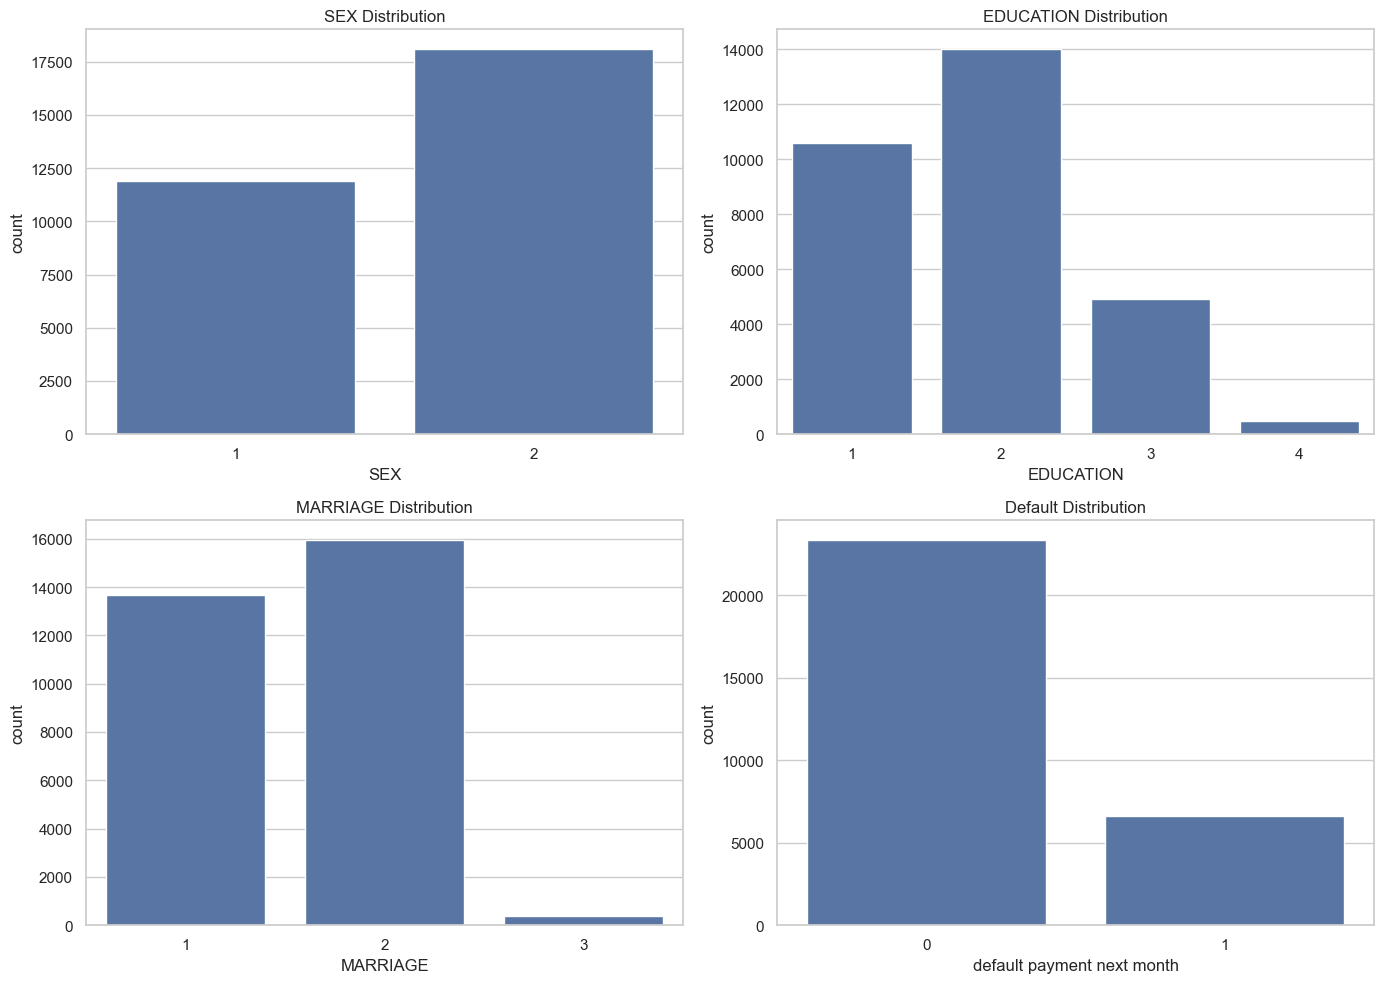

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.countplot(data=card_df, x='SEX', ax=axes[0, 0])
axes[0, 0].set_title('SEX Distribution')

sns.countplot(data=card_df, x='EDUCATION', ax=axes[0, 1])
axes[0, 1].set_title('EDUCATION Distribution')

sns.countplot(data=card_df, x='MARRIAGE', ax=axes[1, 0])
axes[1, 0].set_title('MARRIAGE Distribution')

sns.countplot(data=card_df, x=target_col, ax=axes[1, 1])
axes[1, 1].set_title('Default Distribution')

plt.tight_layout()
plt.show()

## 1.9 수치형 컬럼 확인

In [38]:
numeric_cols = card_df.select_dtypes(include=np.number).columns.tolist()

# 타깃과 ID는 제외해서 보는 경우가 많음 + 카테고리 제외
exclude_cols = ['ID', target_col] + cat_cols
num_cols = [col for col in numeric_cols if col not in exclude_cols]

print("수치형 변수 개수:", len(num_cols))
print(num_cols)

수치형 변수 개수: 14
['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']


## 1.10 주요 수치형 변수 분포 확인

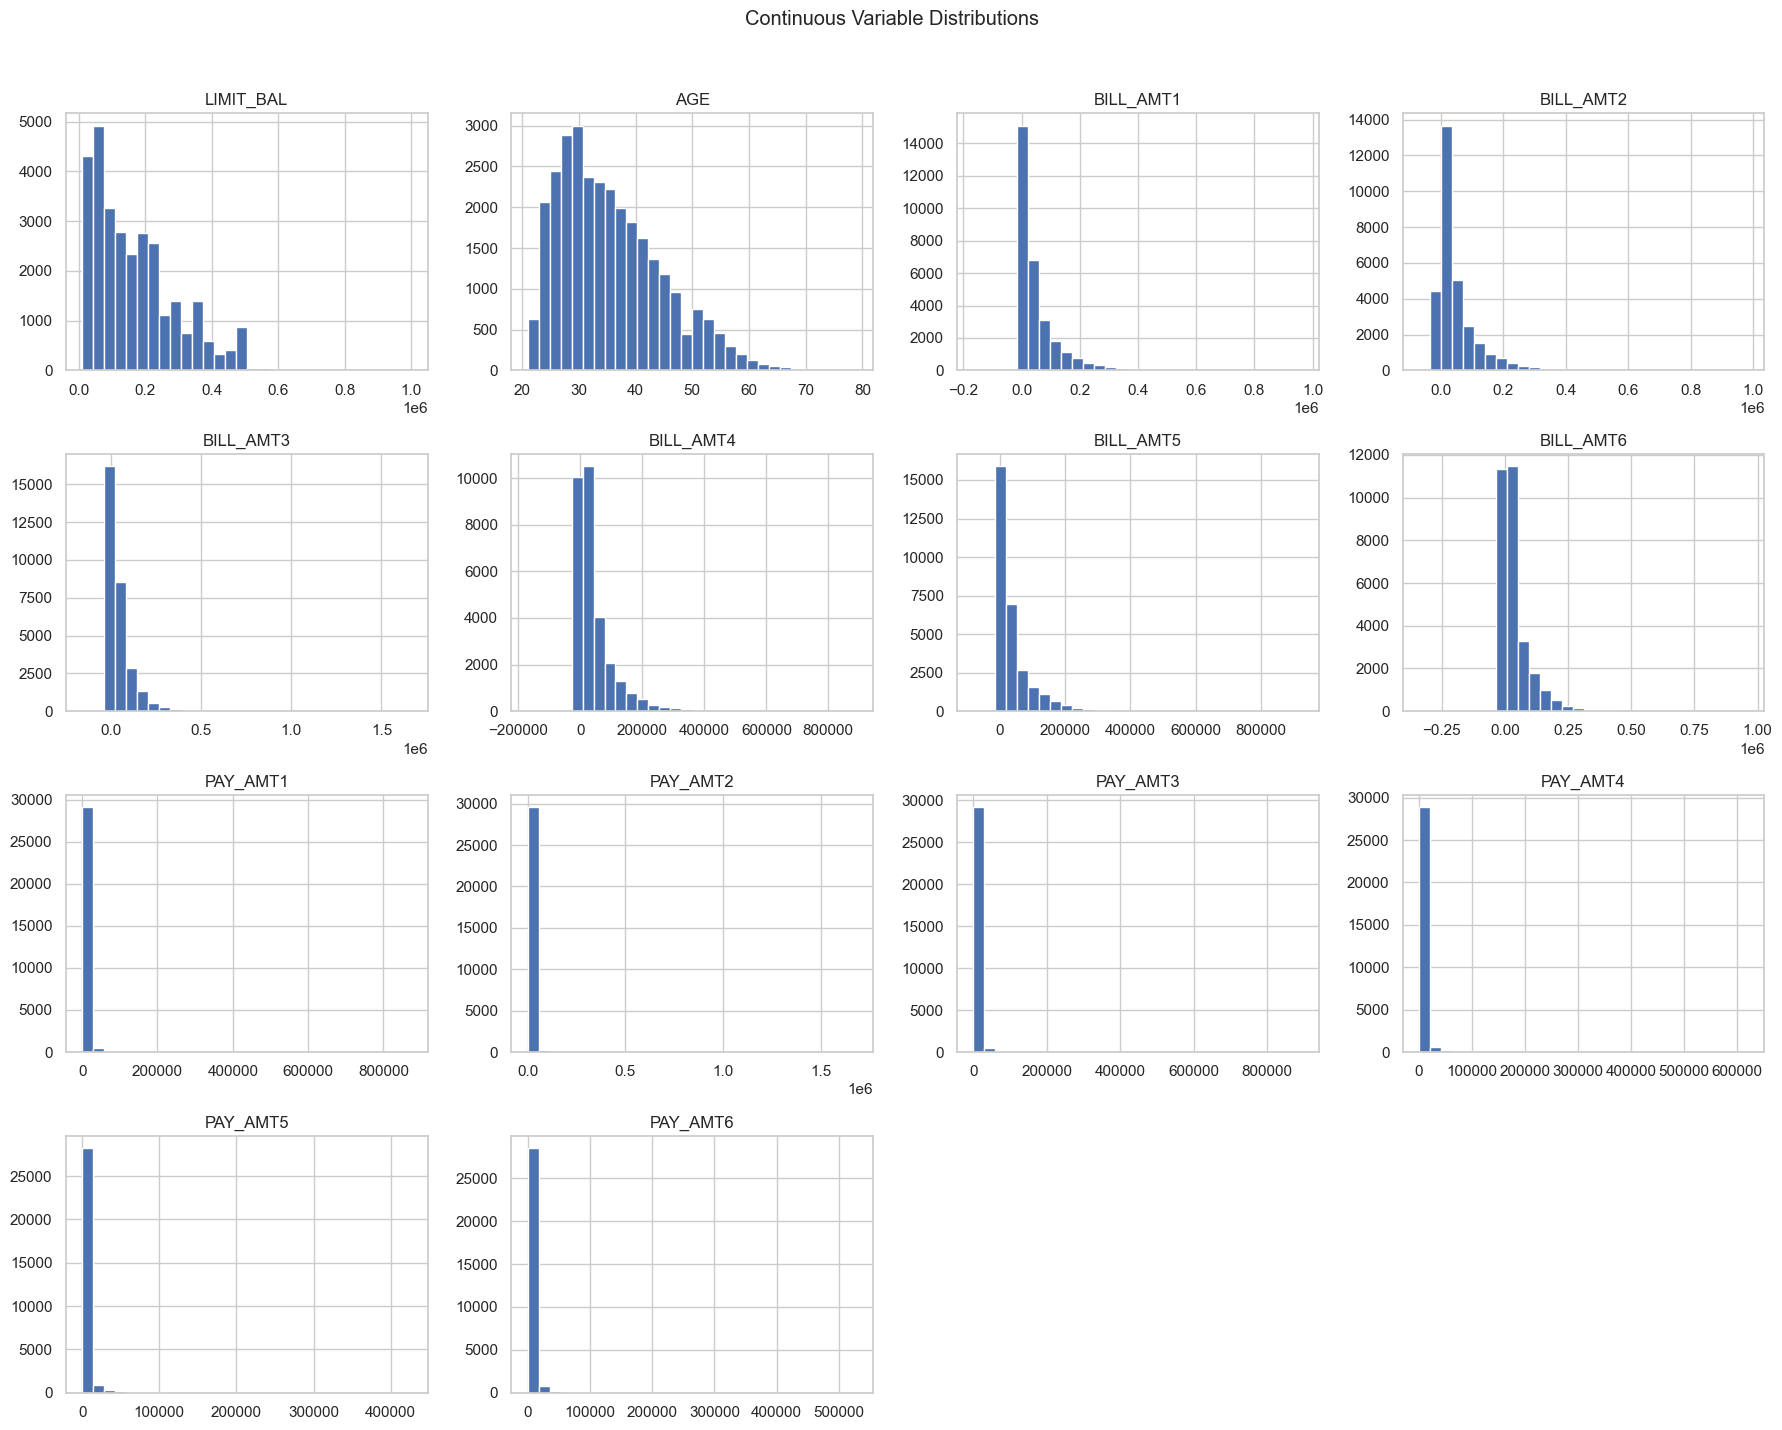

In [39]:
card_df[num_cols].hist(bins=30, figsize=(18, 14))
plt.suptitle("Continuous Variable Distributions", y=1.02)
plt.tight_layout()
plt.show()

# 1.11 Boxplot으로 이상치 후보 보기

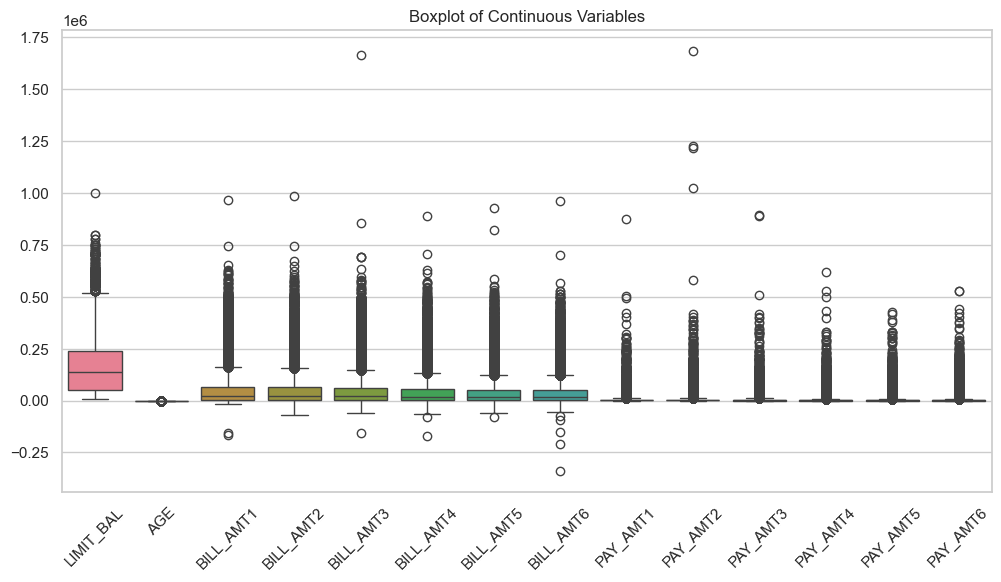

In [40]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=card_df[num_cols])
plt.xticks(rotation=45)
plt.title("Boxplot of Continuous Variables")
plt.show()

## 1.12 변수간 상관관계 분석

In [69]:
# 모든 변수와 target 간 상관관계 계산
corr_with_target = card_df.corr()[target_col].drop([target_col, 'ID'], axis=0)
# corr_with_target = card_df.corr()[target_col].drop(target_col)

# 절대값 기준 정렬
corr_with_target_sorted = corr_with_target.reindex(corr_with_target.abs().sort_values(ascending=False).index)

print("Feature vs Target Correlation")
display(corr_with_target_sorted)

Feature vs Target Correlation


PAY_0        0.324794
PAY_2        0.263551
PAY_3        0.235253
PAY_4        0.216614
PAY_5        0.204149
PAY_6        0.186866
LIMIT_BAL   -0.153520
PAY_AMT1    -0.072929
PAY_AMT2    -0.058579
PAY_AMT4    -0.056827
PAY_AMT3    -0.056250
PAY_AMT5    -0.055124
PAY_AMT6    -0.053183
SEX         -0.039961
EDUCATION    0.033842
MARRIAGE    -0.027575
BILL_AMT1   -0.019644
BILL_AMT2   -0.014193
BILL_AMT3   -0.014076
AGE          0.013890
BILL_AMT4   -0.010156
BILL_AMT5   -0.006760
BILL_AMT6   -0.005372
Name: default payment next month, dtype: float64

* 변수간 상관관계 분석 - 시각화

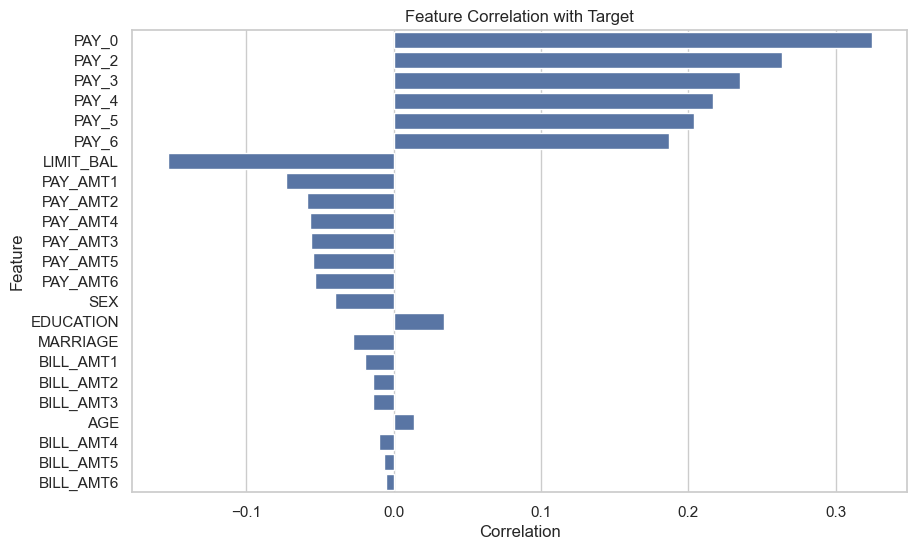

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.barplot(
    x=corr_with_target_sorted.values,
    y=corr_with_target_sorted.index
)

plt.title("Feature Correlation with Target")
plt.xlabel("Correlation")
plt.ylabel("Feature")
plt.show()

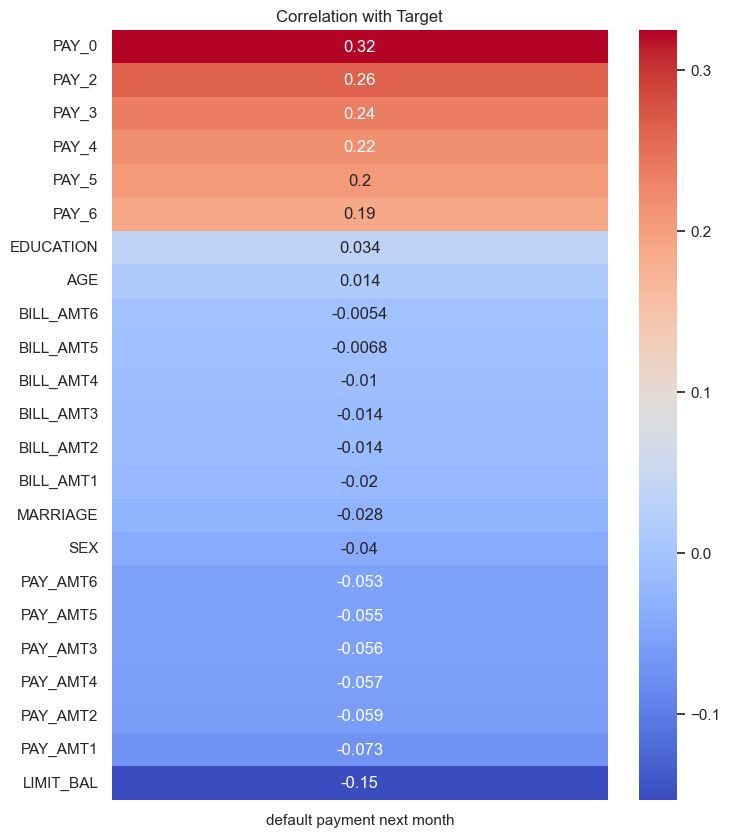

In [73]:
plt.figure(figsize=(8,10))

sns.heatmap(
    card_df.corr()[[target_col]].drop([target_col, 'ID']).sort_values(by=target_col, ascending=False),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation with Target")
plt.show()

# 2. 데이터 가공

## 2.1 X, y 추출

In [ ]:
card_df = card_df.rename(columns={'default payment next month': 'default'})

y_target = card_df['default']
X_features = card_df.drop(columns = ['ID','default'])

X_features, y_target

## 2.2 데이터 분할 : 훈련용 vs 검증용

In [74]:
# Data 분리 및 Scaling
from sklearn.model_selection import train_test_split

# 훈련-검증 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(X_features, y_target, test_size=0.2, random_state=42)


print("X_train shape:", X_train.shape)
print("X_valid shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_valid shape:", y_test.shape)

print("\n[train columns]")
print(X_train.columns.tolist())

X_train shape: (24000, 23)
X_valid shape: (6000, 23)
y_train shape: (24000,)
y_valid shape: (6000,)

[train columns]
['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']


# 3. 모델별 학습 및 예측

- LogisticRegression : 해석이 쉬움, 설명력 우선 - 비교용
- RandomForestClassifier : 튜닝이 상대적으로 쉬움 - 비교 기준으로 적합 
- LGBMClassifier : 성능 우선
- XGBClassifier : 성능 우선

# 3.1 LogisticRegression
- 범주형 변수 인코딩
- 수치형 변수 스케일링
- 모델 학습
- 예측 및 평가  

**Pipeline + ColumnTransformer**

* Column 분류

In [76]:
# categorical / numeric column 분리
cat_cols = ['SEX', 'EDUCATION', 'MARRIAGE',
            'PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']

num_cols = [col for col in X_train.columns if col not in cat_cols]

In [80]:
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix

# preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

# pipeline
lr_model = Pipeline(steps=[   # 수정: model -> lr_model
    ('preprocess', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=1000,
        class_weight='balanced'
    ))
])

# training
lr_model.fit(X_train, y_train)   # 수정: model -> lr_model

# prediction
lr_y_pred = lr_model.predict(X_test)           # 수정: 변수명 변경
lr_y_prob = lr_model.predict_proba(X_test)[:,1] # 수정: 변수명 변경

# evaluation
print("Accuracy:", accuracy_score(y_test, lr_y_pred))   # 수정
print("ROC-AUC:", roc_auc_score(y_test, lr_y_prob))     # 수정

print("\nClassification Report")
print(classification_report(y_test, lr_y_pred))         # 수정

print("\nConfusion Matrix")
print(confusion_matrix(y_test, lr_y_pred))              # 수정

Accuracy: 0.7735
ROC-AUC: 0.7675513821753579

Classification Report
              precision    recall  f1-score   support

           0       0.88      0.83      0.85      4687
           1       0.49      0.58      0.53      1313

    accuracy                           0.77      6000
   macro avg       0.68      0.70      0.69      6000
weighted avg       0.79      0.77      0.78      6000


Confusion Matrix
[[3877  810]
 [ 549  764]]


### 결과 해석

1. Classification Report에서 먼저 확인해야 하는 것은 데이터 불균형입니다

| 클래스 | 의미    | 개수   |
| --- | ----- | ---- |
| 0   | 정상 고객 | 4687 |
| 1   | 부도 고객 | 1313 |

이 데이터는 불균형 데이터입니다. 그래서 Accuracy만으로 모델을 평가하면 안 됩니다.

정상에 비해 부도(class=1)에 대한 예측 성능이 낮아 별도의 조치가 필요함
- 데이터 증식: 부족한 1의 데이터를 늘리는 SMOTE 기법 활용
- 가중치 조정: 모델 학습 시 1에 대해 더 큰 벌점을 주는 Class Weight 설정
- 임계값 조정: Recall을 높이기 위해 분류 임계값(Threshold) 하향 조정


### [개념 정리] ROC-AUC 지표

ROC-AUC는 이진 분류(Binary Classification) 모델의 성능을 측정하는 지표로, 모델이 클래스를 얼마나 잘 구별하는지 수치화한 것입니다.
1. ROC (Receiver Operating Characteristic) 곡선
다양한 임계값(Threshold) 변화에 따른 모델의 분류 성능을 시각적으로 나타낸 그래프입니다.

* X축: FPR (False Positive Rate)
* 실제 음성(Negative) 중 양성(Positive)으로 잘못 예측한 비율입니다. ($1 - \text{특이도}$)
* Y축: TPR (True Positive Rate)
* 실제 양성(Positive) 중 양성으로 올바르게 예측한 비율입니다. (재현율 또는 민감도)
* 해석: 곡선이 왼쪽 상단 구석($0, 1$)에 가깝게 붙을수록 성능이 우수한 모델입니다.

2. AUC (Area Under the Curve)
ROC 곡선 아래의 면적을 의미하며, 모델의 성능을 하나의 숫자로 요약해 줍니다.

| AUC 수치 | 의미 |
|---|---|
| 1.0 | 완벽하게 분류하는 최상의 모델 |
| 0.8 ~ 0.9 | 매우 훌륭한 분류 성능 |
| 0.7 ~ 0.8 | 준수한 분류 성능 |
| 0.5 | 무작위 추측(Random Guess) 수준 |

3. ROC-AUC의 주요 장점

   1. 임계값 독립성: 특정 임계값(0.5 등)에 국한되지 않고, 모델의 전반적인 식별 능력을 평가합니다.
   2. 데이터 불균형에 강함: 정확도(Accuracy)는 클래스 비율이 불균형할 때 왜곡될 수 있지만, ROC-AUC는 양성과 음성 각각의 비율을 고려하므로 더 객관적인 평가가 가능합니다.

# 3.2 RandomForestClassifier

In [82]:
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

# preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

# pipeline
rf_model = Pipeline(steps=[   # 수정: model -> rf_model (모델 구분을 위해 변경)
    ('preprocess', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=42,
        n_jobs=-1,
        class_weight='balanced'
    ))
])

# training
rf_model.fit(X_train, y_train)   # 수정: model -> rf_model

# prediction
rf_y_pred = rf_model.predict(X_test)   # 수정: 결과 변수명 변경
rf_y_prob = rf_model.predict_proba(X_test)[:, 1]   # 수정: 결과 변수명 변경

# evaluation
print("Accuracy:", accuracy_score(y_test, rf_y_pred))   # 수정: rf_y_pred 사용
print("ROC-AUC:", roc_auc_score(y_test, rf_y_prob))     # 수정: rf_y_prob 사용

print("\nClassification Report")
print(classification_report(y_test, rf_y_pred))         # 수정

print("\nConfusion Matrix")
print(confusion_matrix(y_test, rf_y_pred))              # 수정

Accuracy: 0.8153333333333334
ROC-AUC: 0.7630617232834869

Classification Report
              precision    recall  f1-score   support

           0       0.84      0.95      0.89      4687
           1       0.65      0.34      0.44      1313

    accuracy                           0.82      6000
   macro avg       0.74      0.64      0.67      6000
weighted avg       0.80      0.82      0.79      6000


Confusion Matrix
[[4450  237]
 [ 871  442]]


### ROC Curve 비교 그래프 코드

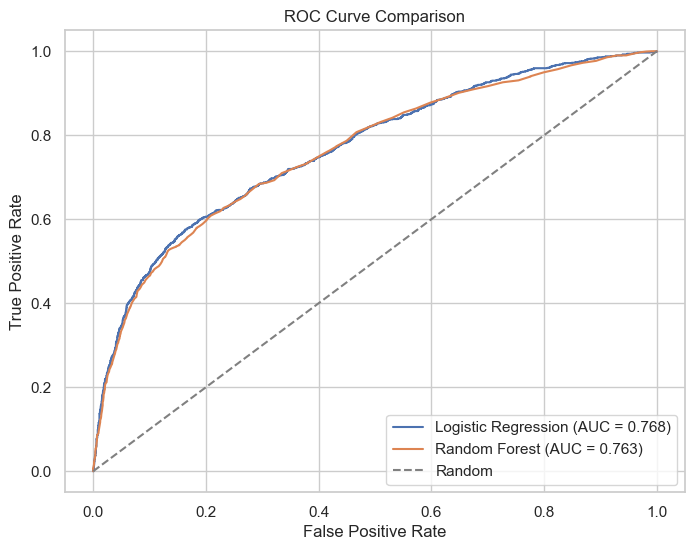

In [83]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# ROC Curve 계산
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_y_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_y_prob)

# AUC 계산
lr_auc = roc_auc_score(y_test, lr_y_prob)
rf_auc = roc_auc_score(y_test, rf_y_prob)

# 그래프 생성
plt.figure(figsize=(8,6))

# Logistic Regression
plt.plot(
    lr_fpr, lr_tpr,
    label=f'Logistic Regression (AUC = {lr_auc:.3f})'
)

# Random Forest
plt.plot(
    rf_fpr, rf_tpr,
    label=f'Random Forest (AUC = {rf_auc:.3f})'
)

# 랜덤 모델 기준선
plt.plot([0,1], [0,1], linestyle='--', color='gray', label='Random')

# 그래프 설정
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')

plt.grid(True)
plt.show()